In [38]:
import numpy as np
import chess
import json
import matplotlib.pyplot as plt
from chessml.encoding.schema import (
    DEFAULT_CACHE_DIR, CACHE_FILES, META_PLY, META_ELO_BUCKET, ELO_BUCKETS,
)
from chessml.encoding.move_vocab import load_move_vocab, VOCAB_SIZE

d = DEFAULT_CACHE_DIR
positions = np.load(d / CACHE_FILES["positions"].format(split="trainval"), mmap_mode="r")
labels    = np.load(d / CACHE_FILES["labels"].format(split="trainval"))
meta      = np.load(d / CACHE_FILES["meta"].format(split="trainval"))
seq_off   = np.load(d / CACHE_FILES["seq_off"].format(split="trainval"))

index_to_move, _ = load_move_vocab()
print(f"{len(labels):,} pozicija iz {len(seq_off) - 1:,} partija")

1,344,731 pozicija iz 20,000 partija


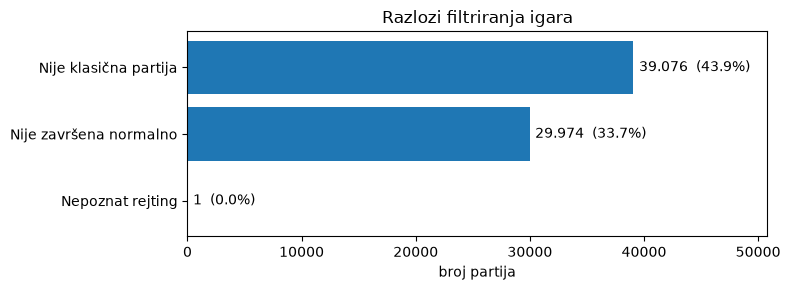

In [39]:
stats = json.loads((DEFAULT_CACHE_DIR / "trainval_stats.json").read_text())
reasons = stats["game_rejection_reasons"]
total_read = stats["games_read"]

LABELS = {
    "termination": "Nije završena normalno",
    "time_control": "Nije klasična partija",
    "unrated": "Neocenjena",
    "missing_elo": "Nepoznat rejting",
    "parse_failed": "Greška pri parsiranju",
}

items = sorted(reasons.items(), key=lambda kv: kv[1])
names = [LABELS.get(key, key) for key, _ in items]
values = [value for _, value in items]

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(names, values)
ax.bar_label(
    bars,
    labels=[f"{v:,}".replace(",", ".") + f"  ({v / total_read:.1%})" for v in values],
    padding=4,
)
ax.set_xlabel("broj partija")
ax.set_xlim(0, max(values) * 1.3)
ax.set_title("Razlozi filtriranja igara")
plt.tight_layout()
plt.show()

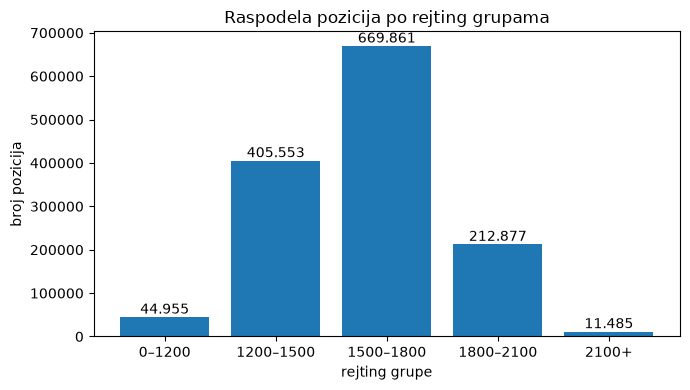

In [50]:
counts = np.bincount(meta[:, META_ELO_BUCKET], minlength=len(ELO_BUCKETS))
names = [f"{lo}–{hi}" if hi < 9999 else f"{lo}+" for lo, hi in ELO_BUCKETS]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(names, counts)
ax.bar_label(bars, labels=[f"{c:,}".replace(",", ".") for c in counts])
ax.set_xlabel("rejting grupe"); ax.set_ylabel("broj pozicija")
ax.set_title("Raspodela pozicija po rejting grupama")
plt.tight_layout(); plt.show()

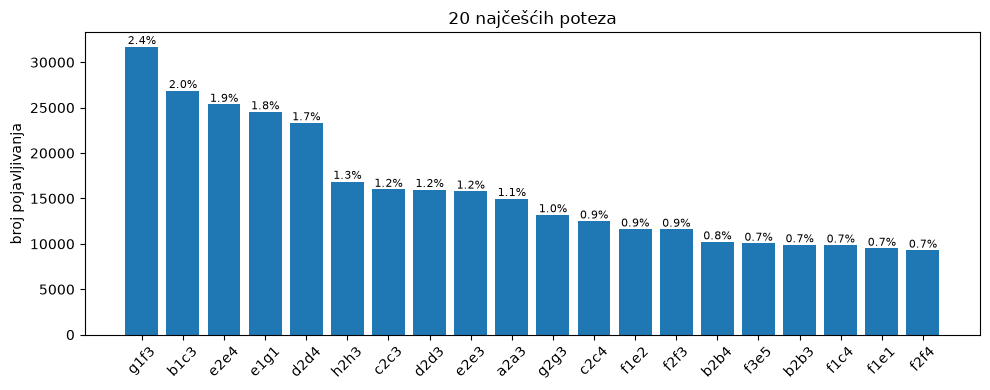

Tačnost modela koji uvek vrati 'g1f3': 2.36%
Najčešćih 20 poteza pokriva 23.7% skupa


In [56]:
move_counts = np.bincount(labels, minlength=VOCAB_SIZE)

top_n = 20
order = np.argsort(move_counts)[::-1][:top_n]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar([index_to_move[i] for i in order], move_counts[order])
ax.bar_label(bars, labels=[f"{move_counts[i] / len(labels):.1%}" for i in order], fontsize=8)
ax.set_ylabel("broj pojavljivanja")
ax.set_title("20 najčešćih poteza")
plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

print(f"Tačnost modela koji uvek vrati '{index_to_move[int(move_counts.argmax())]}': {move_counts.max() / len(labels):.2%}")
print(f"Najčešćih 20 poteza pokriva {move_counts[order].sum() / len(labels):.1%} skupa")

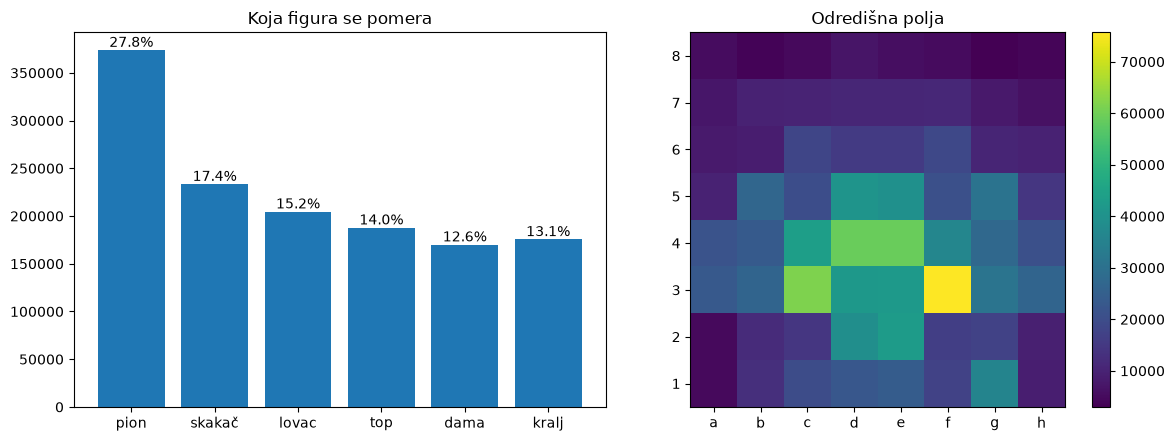

In [49]:
from_sq = np.array([chess.parse_square(m[:2]) for m in index_to_move])
to_sq   = np.array([chess.parse_square(m[2:4]) for m in index_to_move])

moved_piece = np.asarray(positions[np.arange(len(labels)), from_sq[labels]])
assert moved_piece.min() >= 1 and moved_piece.max() <= 6, "mirroring nije dobar"

PIECE_NAMES = ["pion", "skakač", "lovac", "top", "dama", "kralj"]
piece_counts = np.bincount(moved_piece, minlength=7)[1:7]
dest = np.bincount(to_sq[labels], minlength=64).reshape(8, 8)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
bars = axes[0].bar(PIECE_NAMES, piece_counts)
axes[0].bar_label(bars, labels=[f"{c / len(labels):.1%}" for c in piece_counts])
axes[0].set_title("Koja figura se pomera")

im = axes[1].imshow(dest)
axes[1].set_xticks(range(8), list("abcdefgh"))
axes[1].set_yticks(range(8), [str(r) for r in range(8, 0, -1)])
axes[1].set_title("Odredišna polja")
fig.colorbar(im, ax=axes[1])
plt.tight_layout(); plt.show()

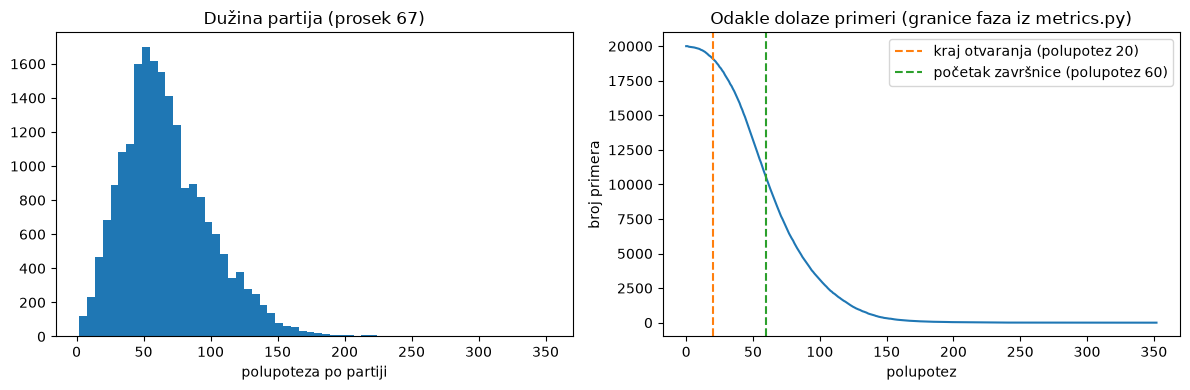

In [31]:
plies_per_game = np.diff(seq_off)
examples_per_ply = np.bincount(meta[:, META_PLY])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(plies_per_game, bins=60)
axes[0].set_xlabel("polupoteza po partiji")
axes[0].set_title(f"Dužina partija (prosek {plies_per_game.mean():.0f})")

axes[1].plot(examples_per_ply)
axes[1].axvline(20, color="tab:orange", ls="--", lw=1.5, label="kraj otvaranja (polupotez 20)")
axes[1].axvline(60, color="tab:green", ls="--", lw=1.5, label="početak završnice (polupotez 60)")
axes[1].legend()
axes[1].set_xlabel("polupotez"); axes[1].set_ylabel("broj primera")
axes[1].set_title("Odakle dolaze primeri (granice faza iz metrics.py)")
plt.tight_layout(); plt.show()

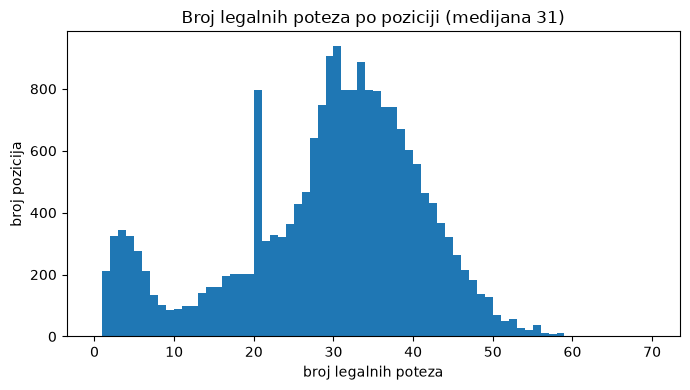

slučajno među legalnim potezima: 6.64%
slučajno među svih 1968 klasa: 0.051%


In [34]:
from chessml.encoding.board_codec import decode_board

rng = np.random.default_rng(0)
sample = rng.choice(len(labels), 20_000, replace=False)
n_legal = np.array([decode_board(positions[i]).legal_moves.count() for i in sample])

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(n_legal, bins=range(0, n_legal.max() + 2))
ax.set_xlabel("broj legalnih poteza"); ax.set_ylabel("broj pozicija")
ax.set_title(f"Broj legalnih poteza po poziciji (medijana {np.median(n_legal):.0f})")
plt.tight_layout(); plt.show()

print(f"slučajno među legalnim potezima: {(1 / n_legal).mean():.2%}")
print(f"slučajno među svih {VOCAB_SIZE} klasa: {1 / VOCAB_SIZE:.3%}")

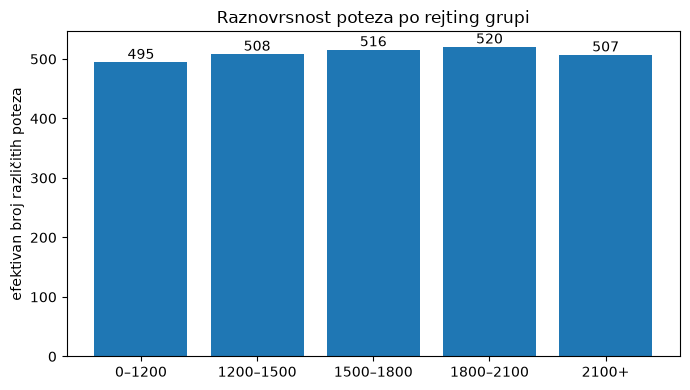

In [37]:
res = []
for b in range(len(ELO_BUCKETS)):
    c = np.bincount(labels[meta[:, META_ELO_BUCKET] == b], minlength=VOCAB_SIZE)
    p = c[c > 0] / c.sum()
    res.append(2 ** (-(p * np.log2(p)).sum()))

names = [f"{lo}–{hi}" if hi < 9999 else f"{lo}+" for lo, hi in ELO_BUCKETS]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(names, perplexities)
ax.bar_label(bars, fmt="%.0f")
ax.set_ylabel("efektivan broj različitih poteza")
ax.set_title("Raznovrsnost poteza po rejting grupi")
plt.tight_layout(); plt.show()